# Panel series diagnostics

This notebook demonstrates independent panel diagnostics and how to combine their summaries with DataFrame merges.

In [5]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath("../.."))
from tinyshift.series import (
    IntermittencyAnalyzer,
    PAMIAnalyzer,
    PredictabilityAnalyzer,
    SeasonalityAnalyzer,
    TrendAnalyzer,
    VarianceRatioAnalyzer,
)

In [6]:
n = 84
steps = np.arange(n)
dates = pd.date_range("2025-01-01", periods=n, freq="D")
rng = np.random.default_rng(42)

smooth = 6 + 1.5 * np.sin(2 * np.pi * steps / 7) + 0.02 * steps
intermittent = np.where(steps % 3 == 0, 3 + rng.uniform(0, 2, n), 0.0)
lumpy = np.where(steps % 4 == 0, rng.lognormal(1.2, 0.9, n), 0.0)

df = pd.concat(
    [
        pd.DataFrame({"unique_id": uid, "ds": dates, "y": values})
        for uid, values in [
            ("smooth_weekly", smooth),
            ("intermittent", intermittent),
            ("lumpy", lumpy),
        ]
    ],
    ignore_index=True,
)
df.head()

,unique_id,ds,y
0,smooth_weekly,2025-01-01,6.000000
1,smooth_weekly,2025-01-02,7.192747
2,smooth_weekly,2025-01-03,7.502392
3,smooth_weekly,2025-01-04,6.710826
4,smooth_weekly,2025-01-05,5.429174


## MSTL decomposition diagnostics

`mstl_diagnostics` decomposes a time series into trend, seasonal, and residual components, and summarizes trend significance, seasonal strength, and residual autocorrelation.

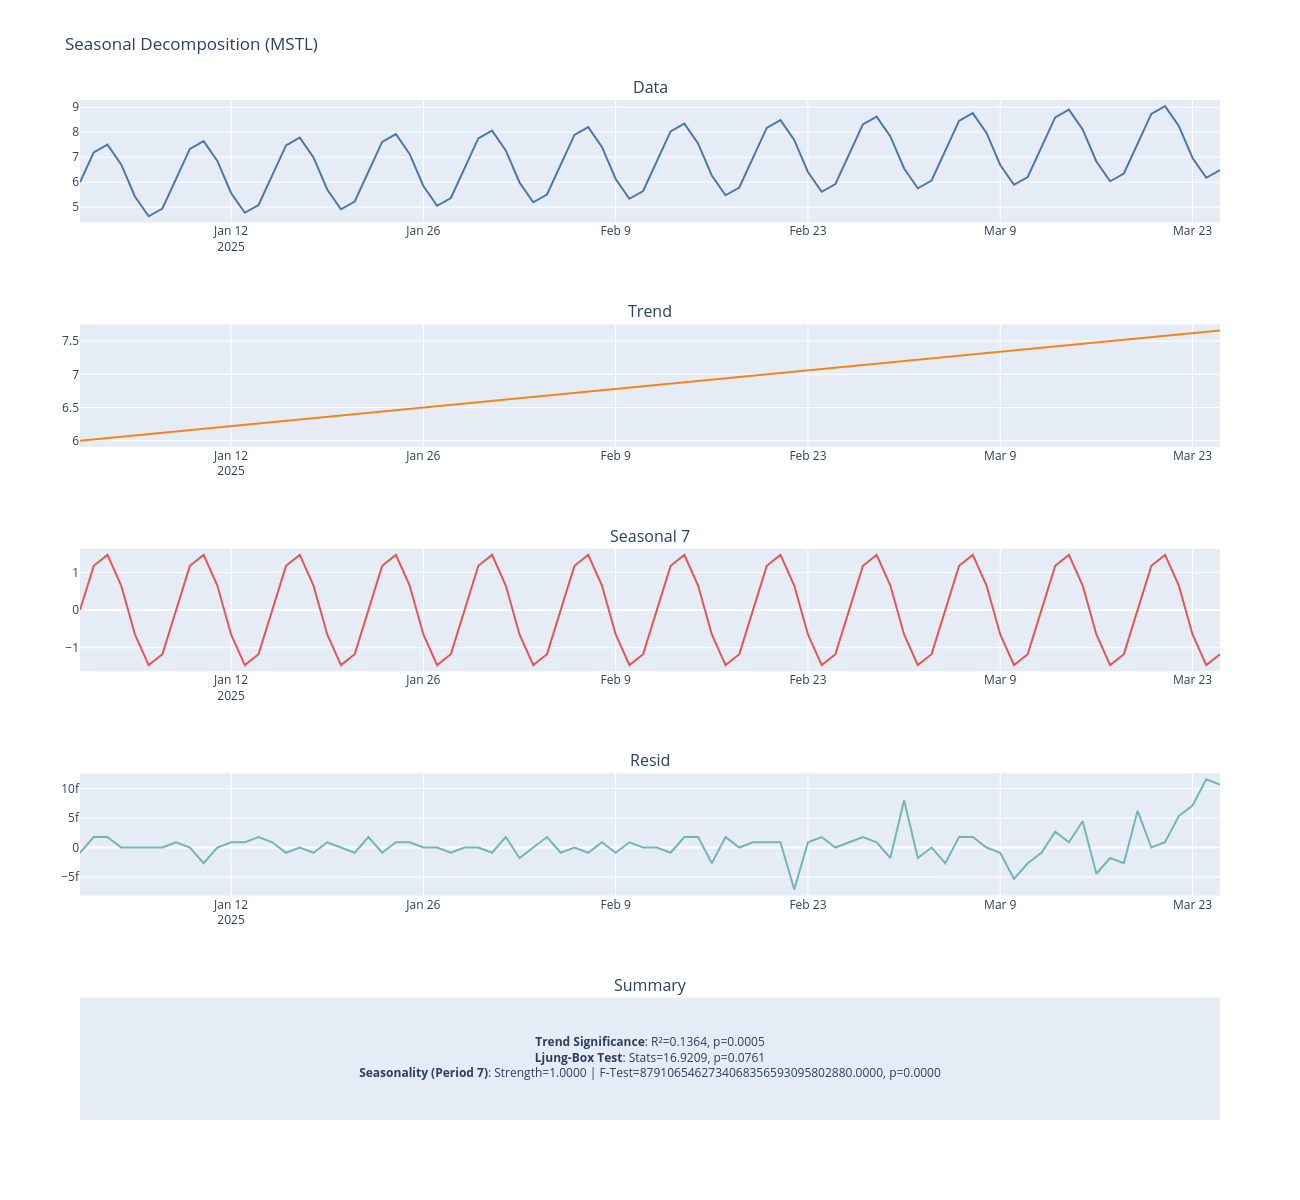

In [7]:
from tinyshift.plot import mstl_diagnostics

smooth_series = pd.Series(smooth, index=dates, name="smooth_weekly")
mstl_diagnostics(smooth_series, periods=7, fig_type="png")

## Demand occurrence

`IntermittencyAnalyzer.summary()` returns the occurrence and magnitude diagnostics for each series. Detailed interval arrays remain available in `results_`.

In [8]:
intermittency = IntermittencyAnalyzer().fit(df)
intermittency.summary()

,unique_id,adi,cv2,zero_proportion,interval_cv,classification
0,intermittent,3.0,0.013614,0.666667,0.0,intermittent
1,lumpy,4.0,1.253091,0.750000,0.0,lumpy
2,smooth_weekly,1.0,0.027822,0.000000,0.0,smooth


## Candidate and significant seasonal periods

The detector profile exposes both `candidate_periods` found from spectral peaks and
`significant_periods` that pass harmonic significance testing. FFT frequencies,
power, and peaks can be inspected through `results_`.

In [9]:
seasonality = SeasonalityAnalyzer(top_k=2).fit(df)
seasonality.summary()

,unique_id,candidate_periods,significant_periods
0,intermittent,"[3, 6]",[3]
1,lumpy,"[2, 4]","[2, 4]"
2,smooth_weekly,[7],[7]


## Variance ratio by horizon

`VarianceRatioAnalyzer.summary()` returns `unique_id`, `horizon`, `variance_ratio`,
and `significant_dependence` for each evaluation. The detailed `z_statistic` and
`p_value` remain available in the analyzer's `results_`. The test evaluates the
random-walk null hypothesis $H_0: VR(horizon) = 1$:

- `variance_ratio > 1` indicates persistence at the evaluated horizon.
- `variance_ratio < 1` indicates anti-persistence or mean reversion.
- `significant_dependence=True` means the null hypothesis was rejected at the
  configured significance level.

Significance indicates serial dependence at a specific horizon, not necessarily
high forecastability. Intermittent or lumpy series can show strong
anti-persistence because of their zero-demand structure. Interpret this output
with the seasonality, trend, and intermittency diagnostics.

In [10]:
variance_ratios = VarianceRatioAnalyzer().fit(df)
variance_ratios.summary()

,unique_id,horizon,variance_ratio,significant_dependence
0,intermittent,2,0.512476,True
1,intermittent,4,0.260014,True
2,intermittent,8,0.139486,True
3,lumpy,2,0.512358,True
4,lumpy,4,0.155191,True
5,lumpy,8,0.068353,True
6,smooth_weekly,2,1.639561,True
7,smooth_weekly,4,1.324506,False
8,smooth_weekly,8,0.138114,True


## PAMI local minima and forecasting lags

`PAMIAnalyzer` keeps lag discovery separate from lag creation. Its summary contains only each SKU and the local minima found in its PAMI curve. Fallback behavior is applied later, when model-compatible lags are created.

In [11]:
pami = PAMIAnalyzer(max_tau=30, normalize=True).fit(df)
pami.summary()

,unique_id,local_minima
0,intermittent,"[4, 7, 10, 13, 18, 22, 25, 27]"
1,lumpy,"[2, 6, 10, 14, 18, 22, 26]"
2,smooth_weekly,"[2, 5, 9, 12, 16, 19, 23, 26]"


In [12]:
# Dictionary accepted directly by DTLWrapper or DMSTLWrapper as `nlags`.
pami.lags(mode="short", short=2, fallback=1)

{'intermittent': [1, 2, 4], 'lumpy': [1, 2], 'smooth_weekly': [1, 2]}

## Predictability and trend

These analyzers expose complementary diagnostic sections for the same panel.

In [13]:
PredictabilityAnalyzer(detrend="linear", permutation_m=5).fit(df).summary()

,unique_id,foreca,limit,spectral_concentration
0,intermittent,0.954999,0.674687,0.957805
1,lumpy,0.197007,0.674238,0.074067
2,smooth_weekly,0.992008,0.593738,0.992513


In [14]:
TrendAnalyzer(significance_level=0.05).fit(df).summary()

,unique_id,trend_slope,trend_r2,trend_pvalue,significant_trend
0,intermittent,-0.002878,0.001274,0.747201,False
1,lumpy,0.014700,0.008430,0.406184,False
2,smooth_weekly,0.017351,0.136375,0.000546,True


## Combining analyzer summaries

The trend, predictability, seasonality, and intermittency analyzers return one
row per series, so their summaries can be combined with a validated one-to-one
merge. `VarianceRatioAnalyzer` is kept separate because it returns one row per
`(unique_id, horizon)` pair; its results should be analyzed across horizons or
aggregated explicitly before joining them to this per-series profile.

In [15]:
analyzers = [
    IntermittencyAnalyzer(),
    PredictabilityAnalyzer(),
    TrendAnalyzer(),
    SeasonalityAnalyzer(top_k=2),
]
summaries = [analyzer.fit(df).summary() for analyzer in analyzers]
combined = summaries[0]
for summary in summaries[1:]:
    combined = combined.merge(summary, on="unique_id", validate="one_to_one")
combined

,unique_id,adi,cv2,zero_proportion,interval_cv,classification,foreca,limit,spectral_concentration,trend_slope,trend_r2,trend_pvalue,significant_trend,candidate_periods,significant_periods
0,intermittent,3.0,0.013614,0.666667,0.0,intermittent,0.954999,0.386935,0.957805,-0.002878,0.001274,0.747201,False,"[3, 6]",[3]
1,lumpy,4.0,1.253091,0.750000,0.0,lumpy,0.197007,0.419804,0.074067,0.014700,0.008430,0.406184,False,"[2, 4]","[2, 4]"
2,smooth_weekly,1.0,0.027822,0.000000,0.0,smooth,0.992008,0.281646,0.992513,0.017351,0.136375,0.000546,True,[7],[7]
